# Feature Engineering Analysis
**UPI Transaction Analytics & Risk Monitoring Platform**

Explores the 31 engineered features — their distributions, fraud correlations, and relative importance.

> Run `main.py` first to generate `data/processed/featured_data.csv`

In [ ]:
%pip install --quiet pandas numpy matplotlib

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': '#0D1117', 'axes.facecolor': '#161B22',
    'axes.edgecolor': '#30363D',   'axes.labelcolor': '#C9D1D9',
    'xtick.color': '#8B949E',      'ytick.color': '#8B949E',
    'text.color': '#C9D1D9',       'grid.color': '#21262D',
    'grid.alpha': 0.6,             'legend.facecolor': '#161B22',
    'legend.edgecolor': '#30363D', 'font.family': 'DejaVu Sans',
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
})
PALETTE = {
    'fraud': '#FF4757', 'legit': '#2ED573', 'medium': '#FFA502',
    'accent': '#1E90FF', 'purple': '#A855F7', 'teal': '#00BCD4',
    'bg_dark': '#0D1117', 'bg_card': '#161B22', 'border': '#30363D', 'text_muted': '#8B949E',
}
FEATURE_COLS = [
    'balance_drain_ratio','is_account_drained','origin_balance_error',
    'has_origin_error','dest_balance_error','has_dest_error',
    'both_balances_wrong','dest_balance_unchanged','zero_origin_before',
    'zero_dest_before','both_zero_after',
    'log_amount','sqrt_amount','is_round_amount','is_large_tx','is_very_large',
    'hour_of_day','day_of_month','is_off_hours','is_weekend',
    'orig_tx_count','orig_mean_amount','orig_std_amount','orig_cv',
    'amount_z_score','orig_total_sent',
    'dest_unique_senders','dest_tx_count','is_high_freq_dest',
    'is_transfer','is_cash_out',
]
df_feat = pd.read_csv('../data/processed/featured_data.csv')
print(f"Loaded: {len(df_feat):,} rows  |  {len(FEATURE_COLS)} engineered features")
df_feat[FEATURE_COLS + ['isFraud']].describe().T.head(10)

Loaded: 44,414 rows  |  31 engineered features


,count,mean,std,min,25%,50%,75%,max
balance_drain_ratio,44414.0,0.939157,0.197814,0.000185,1.0000,1.000,1.0000,1.0
is_account_drained,44414.0,0.890710,0.312006,0.000000,1.0000,1.000,1.0000,1.0
origin_balance_error,44414.0,236220.747479,334477.572540,0.000000,51440.5225,145368.435,284573.5100,6388051.5
has_origin_error,44414.0,0.890553,0.312203,0.000000,1.0000,1.000,1.0000,1.0
dest_balance_error,44414.0,130764.623550,478572.906500,0.000000,0.0000,0.000,100908.4075,25991650.0
has_dest_error,44414.0,0.403004,0.490507,0.000000,0.0000,0.000,1.0000,1.0
both_balances_wrong,44414.0,0.362476,0.480721,0.000000,0.0000,0.000,1.0000,1.0
dest_balance_unchanged,44414.0,0.002837,0.053188,0.000000,0.0000,0.000,0.0000,1.0
zero_origin_before,44414.0,0.470100,0.499111,0.000000,0.0000,0.000,1.0000,1.0
zero_dest_before,44414.0,0.129239,0.335468,0.000000,0.0000,0.000,0.0000,1.0


## 1. Feature–Fraud Correlation Ranking (All 31 Features)

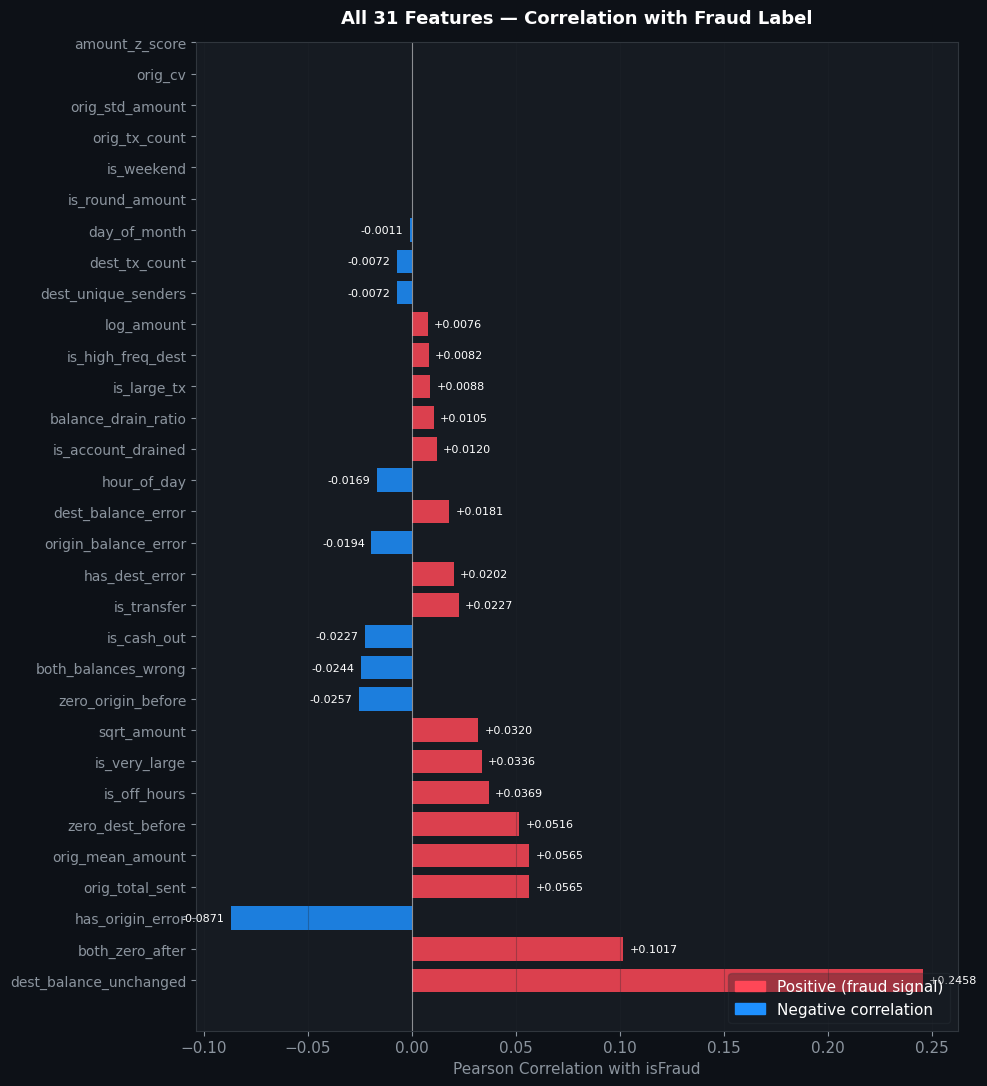

In [2]:
corr_with_fraud = df_feat[FEATURE_COLS + ['isFraud']].corr()['isFraud'].drop('isFraud')
corr_sorted = corr_with_fraud.reindex(corr_with_fraud.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(10, 11), facecolor=PALETTE['bg_dark'])
colors = [PALETTE['fraud'] if v > 0 else PALETTE['accent'] for v in corr_sorted.values]
ax.barh(range(len(corr_sorted)), corr_sorted.values, color=colors, alpha=0.85, height=0.75)
ax.set_yticks(range(len(corr_sorted)))
ax.set_yticklabels(corr_sorted.index, fontsize=10)
ax.axvline(0, color='white', linewidth=0.8, alpha=0.5)
for i, val in enumerate(corr_sorted.values):
    x_pos = val + 0.003 if val >= 0 else val - 0.003
    ax.text(x_pos, i, f'{val:+.4f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8, color='white')
ax.set_xlabel('Pearson Correlation with isFraud', color=PALETTE['text_muted'])
ax.set_title('All 31 Features — Correlation with Fraud Label', color='white', pad=14)
legend_els = [mpatches.Patch(color=PALETTE['fraud'],  label='Positive (fraud signal)'),
              mpatches.Patch(color=PALETTE['accent'], label='Negative correlation')]
ax.legend(handles=legend_els, labelcolor='white', framealpha=0.3, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Feature Correlation Heatmap (Top 14 Features)

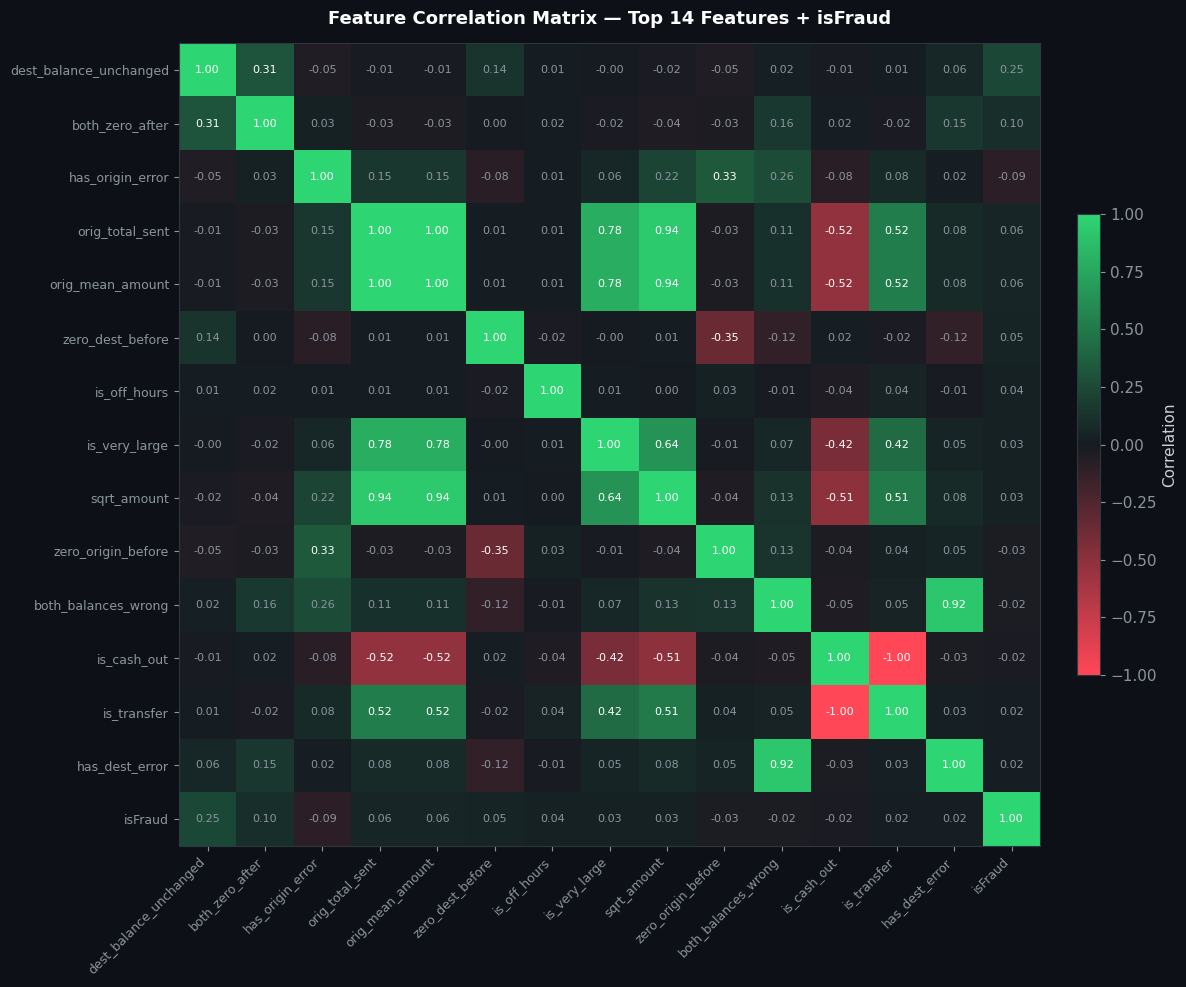

In [3]:
top_features = corr_with_fraud.abs().sort_values(ascending=False).head(14).index.tolist()
corr_matrix  = df_feat[top_features + ['isFraud']].corr()

fig, ax = plt.subplots(figsize=(12, 10), facecolor=PALETTE['bg_dark'])
cmap = LinearSegmentedColormap.from_list('rg', ['#FF4757', '#161B22', '#2ED573'])
im = ax.imshow(corr_matrix, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_matrix.columns, fontsize=9)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(val) > 0.3 else PALETTE['text_muted'])
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.04, label='Correlation')
ax.set_title('Feature Correlation Matrix — Top 14 Features + isFraud', color='white', pad=14)
plt.tight_layout()
plt.show()

## 3. Fraud Rate When Binary Feature is Active

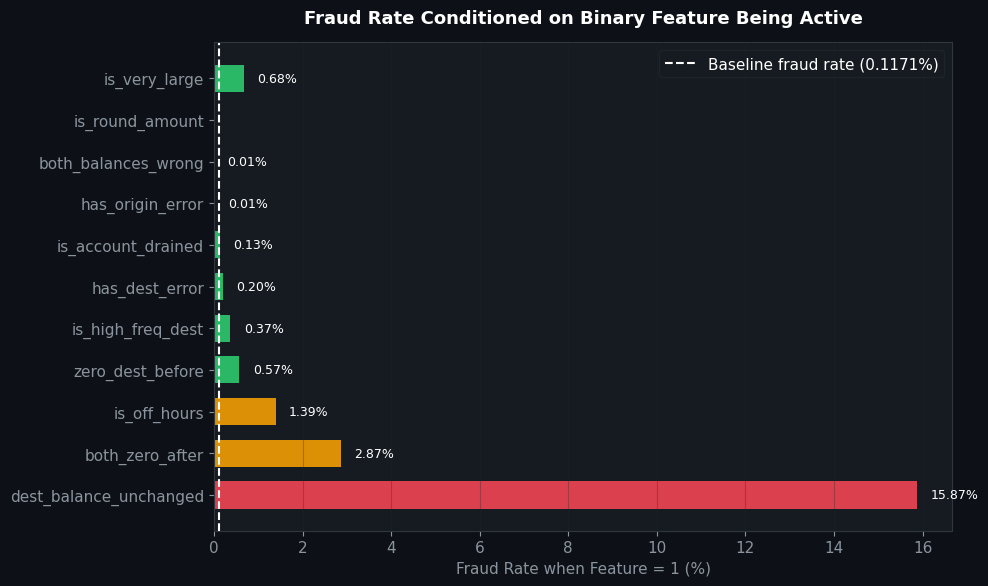

In [4]:
binary_features = [
    'is_account_drained','has_origin_error','has_dest_error',
    'both_balances_wrong','dest_balance_unchanged',
    'zero_dest_before','both_zero_after','is_high_freq_dest',
    'is_off_hours','is_round_amount','is_very_large',
]
fraud_rates = {feat: df_feat[df_feat[feat]==1]['isFraud'].mean()*100 for feat in binary_features}
fraud_rates = dict(sorted(fraud_rates.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(10, 6), facecolor=PALETTE['bg_dark'])
bar_colors = [PALETTE['fraud'] if v>5 else (PALETTE['medium'] if v>1 else PALETTE['legit'])
              for v in fraud_rates.values()]
bars = ax.barh(list(fraud_rates.keys()), list(fraud_rates.values()),
               color=bar_colors, alpha=0.85, height=0.65)
for bar, val in zip(bars, fraud_rates.values()):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9, color='white')
baseline = df_feat['isFraud'].mean() * 100
ax.axvline(baseline, color='white', linestyle='--', linewidth=1.5,
           label=f'Baseline fraud rate ({baseline:.4f}%)')
ax.set_xlabel('Fraud Rate when Feature = 1 (%)', color=PALETTE['text_muted'])
ax.set_title('Fraud Rate Conditioned on Binary Feature Being Active', color='white', pad=14)
ax.legend(labelcolor='white', framealpha=0.3)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Distribution of Key Continuous Features

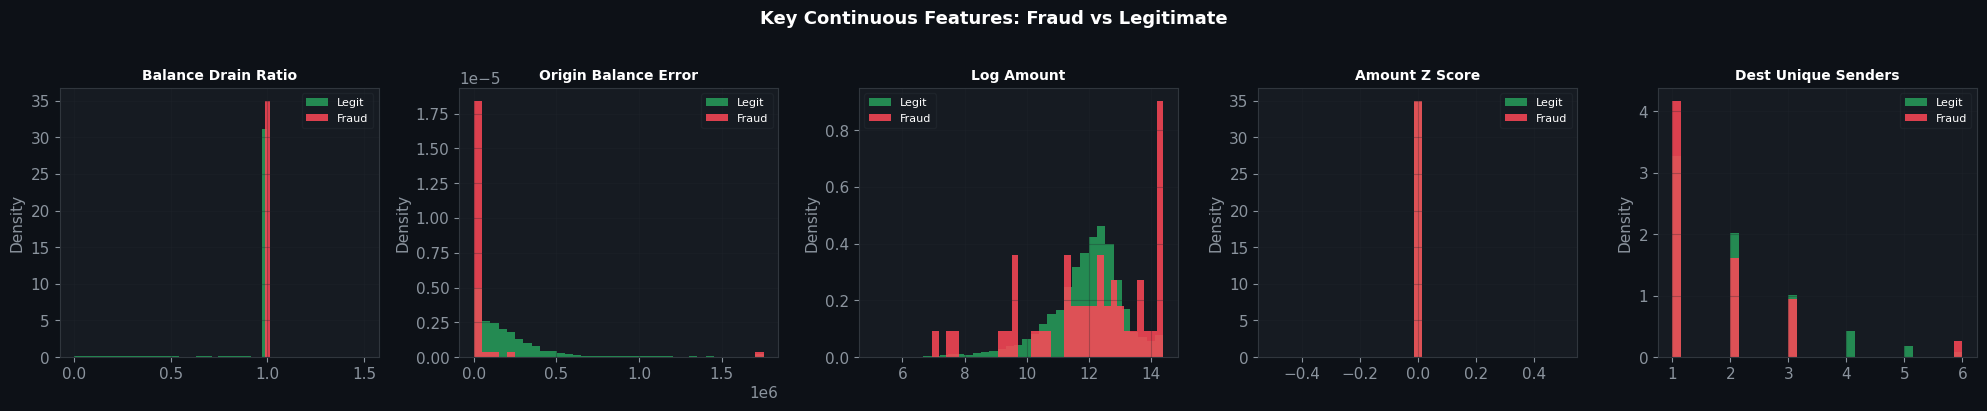

In [5]:
continuous_features = ['balance_drain_ratio','origin_balance_error',
                       'log_amount','amount_z_score','dest_unique_senders']

fig, axes = plt.subplots(1, len(continuous_features), figsize=(20, 4), facecolor=PALETTE['bg_dark'])
fig.suptitle('Key Continuous Features: Fraud vs Legitimate', fontsize=13, fontweight='bold', color='white', y=1.02)

for ax, feat in zip(axes, continuous_features):
    legit_v = df_feat[df_feat['isFraud']==0][feat].dropna().sample(
        min(5000,(df_feat['isFraud']==0).sum()), random_state=42)
    fraud_v = df_feat[df_feat['isFraud']==1][feat].dropna()
    clip_max = legit_v.quantile(0.99)
    ax.hist(legit_v.clip(upper=clip_max), bins=35, alpha=0.6, color=PALETTE['legit'],
            label='Legit', density=True, edgecolor='none')
    ax.hist(fraud_v.clip(upper=clip_max), bins=35, alpha=0.85, color=PALETTE['fraud'],
            label='Fraud', density=True, edgecolor='none')
    ax.set_title(feat.replace('_',' ').title(), color='white', fontsize=10)
    ax.set_ylabel('Density', color=PALETTE['text_muted'])
    ax.legend(labelcolor='white', framealpha=0.3, fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Feature Mean Comparison: Fraud vs Legitimate

In [6]:
summary = df_feat.groupby('isFraud')[FEATURE_COLS].mean().T
summary.columns = ['Legitimate (mean)', 'Fraud (mean)']
summary['Lift'] = (summary['Fraud (mean)'] / summary['Legitimate (mean)'].replace(0, 1e-9)).round(2)
summary = summary.sort_values('Lift', ascending=False)
print("Feature Means by Class (sorted by Fraud/Legit lift):")
print(summary.to_string())

Feature Means by Class (sorted by Fraud/Legit lift):
                        Legitimate (mean)   Fraud (mean)    Lift
dest_balance_unchanged           0.002389       0.384615  160.97
both_zero_after                  0.015238       0.384615   25.24
is_off_hours                     0.009580       0.115385   12.04
is_very_large                    0.039268       0.230769    5.88
zero_dest_before                 0.128646       0.634615    4.93
is_high_freq_dest                0.012082       0.038462    3.18
orig_total_sent             268497.331408  833078.005577    3.10
orig_mean_amount            268497.331408  833078.005577    3.10
dest_balance_error          130468.067037  383761.546897    2.94
is_transfer                      0.184843       0.442308    2.39
has_dest_error                   0.402664       0.692308    1.72
sqrt_amount                    455.444389     687.711211    1.51
is_large_tx                      0.448244       0.576923    1.29
is_account_drained               0.89